# Preanálisis (EDA) – Brecha digital en el Valle del Cauca

**Proyecto ETL – Entrega 2** · Universidad Autónoma de Occidente · Curso GyAD (prof. Juan Manuel Núñez)
Integrantes: Samuel Arredondo Delgado, Cristian Andrés Mera Giraldo, Luis Carlos Lozano Giraldo, Emmanuel Medina Gutiérrez.

Este notebook lee las capas **Silver** y **Gold** generadas por `python main.py` y responde las preguntas P1–P5 usando **Matplotlib**.

## 0. Carga de datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml

In [2]:
# Ruta raíz del proyecto: el notebook está en notebooks/, así que la raíz es la carpeta de arriba.
# (No se usan rutas absolutas como C:/Users/..., para que funcione en cualquier computador.)
if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath("..")
else:
    PROJECT_ROOT = os.getcwd()

CONFIG_PATH = os.path.join(PROJECT_ROOT, "config", "config.yaml")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

# Carpeta donde se guardan las gráficas (definida en config.yaml)
FIGURES_DIR = os.path.join(PROJECT_ROOT, config["paths"]["figures_dir"])
os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
# Construcción de rutas combinando la raíz y lo que está en config.yaml
path_internet = os.path.join(PROJECT_ROOT, config["sources"]["internet_fijo"]["silver"])
path_movil = os.path.join(PROJECT_ROOT, config["sources"]["cobertura_movil"]["silver"])
path_men = os.path.join(PROJECT_ROOT, config["sources"]["men_educacion"]["silver"])
path_saber = os.path.join(PROJECT_ROOT, config["sources"]["saber11"]["silver"])
path_poblacion = os.path.join(PROJECT_ROOT, config["sources"]["poblacion_dane"]["silver"])

# Carga de archivos CSV de Silver (cod_mpio siempre como texto para no perder los ceros)
internet_df = pd.read_csv(path_internet, dtype={"cod_mpio": str})
movil_df = pd.read_csv(path_movil, dtype={"cod_mpio": str, "cod_centro_poblado": str})
men_df = pd.read_csv(path_men, dtype={"cod_mpio": str})
saber_df = pd.read_csv(path_saber, dtype={"cod_mpio": str})
poblacion_df = pd.read_csv(path_poblacion, dtype={"cod_mpio": str})

display(internet_df.tail())
print("--------------------------------------------------")
display(movil_df.tail())
print("--------------------------------------------------")
display(men_df.tail())
print("--------------------------------------------------")
display(saber_df.tail())
print("--------------------------------------------------")
display(poblacion_df.tail())

,anio,trimestre,proveedor,cod_mpio,municipio,segmento,tecnologia,accesos,velocidad_bajada_mbps,es_residencial
247108,2018,4,telmex colombia s.a.,76520,palmira,residencial - estrato 3,cable,2,40.0,1
247109,2020,4,directv colombia ltda,76834,tuluá,residencial - estrato 4,otras tecnologías inalámbricas,5,30.0,1
247110,2019,4,empresas municipales de cali eice e.s.p,76364,jamundí,residencial - estrato 2,xdsl,10,2.0,1
247111,2019,2,radionet soluciones s.a.,76520,palmira,corporativo,wifi,1,5.0,0
247112,2018,4,colombia telecomunicaciones s.a. e.s.p.,76122,caicedonia,residencial - estrato 1,xdsl,60,3.0,1


--------------------------------------------------


,anio,trimestre,proveedor,cod_mpio,municipio,cabecera_municipal,cod_centro_poblado,centro_poblado,cobertura_2g,cobertura_3g,cobertura_hspa,cobertura_5g,tiene_4g
26817,2019,2,comunicacion celular s a comcel s a,76863,versalles,0,76863007,la florida,0,0,0,0,0
26818,2020,1,comunicacion celular s a comcel s a,76109,buenaventura,0,76109047,pianguita,0,0,0,0,0
26819,2015,4,comunicacion celular s a comcel s a,76001,cali,0,76001030,las palmas,0,0,0,0,0
26820,2015,4,comunicacion celular s a comcel s a,76109,buenaventura,0,76109034,san isidro,0,0,0,0,0
26821,2019,2,comunicacion celular s a comcel s a,76377,la cumbre,0,76377003,lomitas,0,0,0,0,0


--------------------------------------------------


,anio,cod_mpio,municipio,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_bruta,cobertura_neta_media,tamano_promedio_grupo,sedes_conectadas_a_internet,desercion,aprobacion,reprobacion,repitencia
583,2024,76863,versalles,1356.0,65.34,65.34,71.68,42.48,NaN,NaN,4.66,91.87,3.47,7.38
584,2024,76869,vijes,2377.0,67.40,67.40,76.74,44.72,NaN,NaN,7.09,88.92,3.99,5.60
585,2024,76890,yotoco,3038.0,78.01,78.01,89.20,47.80,NaN,NaN,4.09,90.28,5.63,6.81
586,2024,76892,yumbo,20444.0,104.26,103.19,114.16,58.87,NaN,NaN,5.49,86.10,8.41,9.98
587,2024,76895,zarzal,8329.0,72.29,72.29,81.43,50.07,NaN,NaN,4.10,92.90,3.00,5.75


--------------------------------------------------


,estu_consecutivo,periodo,anio,semestre,cod_mpio,municipio,zona,colegio_oficial,estrato,tiene_computador,tiene_internet,punt_global
295183,AC202210009314,20221,2022,1,76001,cali,urbano,0,3.0,1.0,1.0,311.0
295184,AC202210015252,20221,2022,1,76622,roldanillo,urbano,0,4.0,1.0,1.0,347.0
295185,AC202210012978,20221,2022,1,76001,cali,urbano,0,3.0,0.0,1.0,267.0
295186,AC202210028144,20221,2022,1,76130,candelaria,urbano,0,1.0,1.0,1.0,260.0
295187,AC202210010680,20221,2022,1,76001,cali,urbano,0,3.0,1.0,1.0,283.0


--------------------------------------------------


,cod_mpio,municipio,anio,area,poblacion,serie
4783,76895,zarzal,2041,rural,8590,proyeccion
4784,76895,zarzal,2041,total,43037,proyeccion
4785,76895,zarzal,2042,cabecera,34320,proyeccion
4786,76895,zarzal,2042,rural,8506,proyeccion
4787,76895,zarzal,2042,total,42826,proyeccion


In [4]:
# Carga de las tablas Gold
dim_df = pd.read_csv(os.path.join(PROJECT_ROOT, config["gold"]["dim_municipio"]), dtype={"cod_mpio": str})
brecha_df = pd.read_csv(os.path.join(PROJECT_ROOT, config["gold"]["brecha_urbano_rural"]), dtype={"cod_mpio": str})
municipio_anio_df = pd.read_csv(os.path.join(PROJECT_ROOT, config["gold"]["municipio_anio"]), dtype={"cod_mpio": str})
ranking_df = pd.read_csv(os.path.join(PROJECT_ROOT, config["gold"]["ranking_priorizacion"]), dtype={"cod_mpio": str})

display(municipio_anio_df.tail())
print("--------------------------------------------------")
display(ranking_df.head())

# Año del ranking (último año común de las fuentes)
anio = config["constant"]["anio_ranking"]
print("Año de análisis:", anio)

,cod_mpio,municipio,anio,poblacion_total,pct_poblacion_rural,trimestre_fijo,accesos_fijos_total,accesos_fijos_residenciales,accesos_por_100_hab,accesos_residenciales_por_100_hab,...,pct_centros_poblados_4g,cobertura_neta,cobertura_bruta,desercion,sedes_conectadas_a_internet,saber11_anio_completo,n_estudiantes_saber11,pct_estudiantes_con_internet,pct_estudiantes_con_computador,punt_global_prom
247,76895,zarzal,2018,41923,24.11,4,4998,4579,11.92,10.92,...,20.00,79.38,94.65,4.93,NaN,0,NaN,NaN,NaN,NaN
248,76895,zarzal,2019,42402,23.86,4,5346,4932,12.61,11.63,...,20.00,77.93,92.51,3.89,NaN,1,458.0,64.63,57.05,231.98
249,76895,zarzal,2020,42888,23.58,4,4462,4025,10.40,9.38,...,20.00,77.93,90.16,3.63,NaN,0,NaN,NaN,NaN,NaN
250,76895,zarzal,2021,43207,23.37,4,5244,4815,12.14,11.14,...,50.00,78.74,92.20,5.65,NaN,0,NaN,NaN,NaN,NaN
251,76895,zarzal,2022,43433,23.20,4,6161,5915,14.19,13.62,...,66.67,75.33,86.46,4.49,NaN,1,472.0,80.86,50.89,236.97


--------------------------------------------------


,cod_mpio,municipio,anio,accesos_residenciales_por_100_hab,operadores_4g,pct_estudiantes_con_internet,punt_global_prom,cobertura_neta,desercion,accesos_residenciales_por_100_hab_norm,operadores_4g_norm,pct_estudiantes_con_internet_norm,punt_global_prom_norm,cobertura_neta_norm,desercion_norm,variables_con_dato,indice,posicion,nivel,prioritario
0,76100,bolívar,2022,2.80,3,64.75,249.55,76.83,9.16,0.0815,0.0,0.3914,0.6338,0.4656,0.0969,6,0.2782,1,bajo,1
1,76243,el águila,2022,0.86,4,49.46,234.83,68.07,9.25,0.0000,1.0,0.0070,0.3815,0.2624,0.0855,6,0.2894,2,bajo,1
2,76054,argelia,2022,2.96,4,60.87,212.58,72.28,8.92,0.0883,1.0,0.2939,0.0000,0.3600,0.1276,6,0.3116,3,bajo,1
3,76020,alcalá,2022,9.29,4,57.04,223.42,66.55,9.92,0.3544,1.0,0.1976,0.1858,0.2271,0.0000,6,0.3275,4,bajo,1
4,76403,la victoria,2022,11.68,3,61.36,228.07,82.90,7.31,0.4548,0.0,0.3062,0.2656,0.6064,0.3329,6,0.3276,5,bajo,1


Año de análisis: 2022


## 1. Calidad de datos

### 1.1 Tipos de datos

In [5]:
# Tipos de datos
print(internet_df.info())
print("--------------------------------------------------")
print(movil_df.info())
print("--------------------------------------------------")
print(men_df.info())
print("--------------------------------------------------")
print(saber_df.info())
print("--------------------------------------------------")
print(poblacion_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 247113 entries, 0 to 247112
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   anio                   247113 non-null  int64  
 1   trimestre              247113 non-null  int64  
 2   proveedor              247113 non-null  str    
 3   cod_mpio               247113 non-null  str    
 4   municipio              247113 non-null  str    
 5   segmento               247113 non-null  str    
 6   tecnologia             247113 non-null  str    
 7   accesos                247113 non-null  int64  
 8   velocidad_bajada_mbps  247113 non-null  float64
 9   es_residencial         247113 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 18.9 MB


None
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 26822 entries, 0 to 26821
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   anio                26822 non-null  int64
 1   trimestre           26822 non-null  int64
 2   proveedor           26822 non-null  str  
 3   cod_mpio            26822 non-null  str  
 4   municipio           26822 non-null  str  
 5   cabecera_municipal  26822 non-null  int64
 6   cod_centro_poblado  22845 non-null  str  
 7   centro_poblado      26822 non-null  str  
 8   cobertura_2g        26822 non-null  int64
 9   cobertura_3g        26822 non-null  int64
 10  cobertura_hspa      26822 non-null  int64
 11  cobertura_5g        26822 non-null  int64
 12  tiene_4g            26822 non-null  int64
dtypes: int64(8), str(5)
memory usage: 2.7 MB
None
--------------------------------------------------


<class 'pandas.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   anio                         588 non-null    int64  
 1   cod_mpio                     588 non-null    str    
 2   municipio                    588 non-null    str    
 3   poblacion_5_16               588 non-null    float64
 4   tasa_matriculacion_5_16      588 non-null    float64
 5   cobertura_neta               588 non-null    float64
 6   cobertura_bruta              588 non-null    float64
 7   cobertura_neta_media         588 non-null    float64
 8   tamano_promedio_grupo        290 non-null    float64
 9   sedes_conectadas_a_internet  294 non-null    float64
 10  desercion                    585 non-null    float64
 11  aprobacion                   588 non-null    float64
 12  reprobacion                  588 non-null    float64
 13  repitencia                   58

<class 'pandas.DataFrame'>
RangeIndex: 295188 entries, 0 to 295187
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   estu_consecutivo  295188 non-null  str    
 1   periodo           295188 non-null  int64  
 2   anio              295188 non-null  int64  
 3   semestre          295188 non-null  int64  
 4   cod_mpio          295188 non-null  str    
 5   municipio         295188 non-null  str    
 6   zona              295183 non-null  str    
 7   colegio_oficial   295188 non-null  int64  
 8   estrato           283613 non-null  float64
 9   tiene_computador  288035 non-null  float64
 10  tiene_internet    284147 non-null  float64
 11  punt_global       295188 non-null  float64
dtypes: float64(4), int64(4), str(4)
memory usage: 27.0 MB
None
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 4788 entries, 0 to 4787
Data columns (total 6 columns):
 #   Column     No

### 1.2 Valores nulos

In [6]:
# Identificar valores nulos por fuente
print("Internet fijo:")
print(internet_df.isnull().sum())
print("--------------------------------------------------")
print("Cobertura móvil:")
print(movil_df.isnull().sum())
print("--------------------------------------------------")
print("MEN:")
print(men_df.isnull().sum())
print("--------------------------------------------------")
print("Saber 11:")
print(saber_df.isnull().sum())
print("--------------------------------------------------")
print("Población DANE:")
print(poblacion_df.isnull().sum())
print("--------------------------------------------------")
print("Años con deserción vacía en el MEN:", men_df[men_df["desercion"].isnull()]["anio"].tolist())
print("Años con dato de sedes_conectadas_a_internet:", sorted(men_df[men_df["sedes_conectadas_a_internet"].notnull()]["anio"].unique().tolist()))

Internet fijo:
anio                     0
trimestre                0
proveedor                0
cod_mpio                 0
municipio                0
segmento                 0
tecnologia               0
accesos                  0
velocidad_bajada_mbps    0
es_residencial           0
dtype: int64
--------------------------------------------------
Cobertura móvil:


anio                     0
trimestre                0
proveedor                0
cod_mpio                 0
municipio                0
cabecera_municipal       0
cod_centro_poblado    3977
centro_poblado           0
cobertura_2g             0
cobertura_3g             0
cobertura_hspa           0
cobertura_5g             0
tiene_4g                 0
dtype: int64
--------------------------------------------------
MEN:
anio                             0
cod_mpio                         0
municipio                        0
poblacion_5_16                   0
tasa_matriculacion_5_16          0
cobertura_neta                   0
cobertura_bruta                  0
cobertura_neta_media             0
tamano_promedio_grupo          298
sedes_conectadas_a_internet    294
desercion                        3
aprobacion                       0
reprobacion                      0
repitencia                       0
dtype: int64
--------------------------------------------------
Saber 11:


estu_consecutivo        0
periodo                 0
anio                    0
semestre                0
cod_mpio                0
municipio               0
zona                    5
colegio_oficial         0
estrato             11575
tiene_computador     7153
tiene_internet      11041
punt_global             0
dtype: int64
--------------------------------------------------
Población DANE:


cod_mpio     0
municipio    0
anio         0
area         0
poblacion    0
serie        0
dtype: int64
--------------------------------------------------
Años con deserción vacía en el MEN: [2011, 2011, 2011]
Años con dato de sedes_conectadas_a_internet: [2011, 2012, 2013, 2014, 2015, 2016, 2017]


saber11  zona                            0.00
men      desercion                       0.51
saber11  tiene_computador                2.42
         tiene_internet                  3.74
         estrato                         3.92
movil    cod_centro_poblado             14.83
men      sedes_conectadas_a_internet    50.00
         tamano_promedio_grupo          50.68
dtype: float64

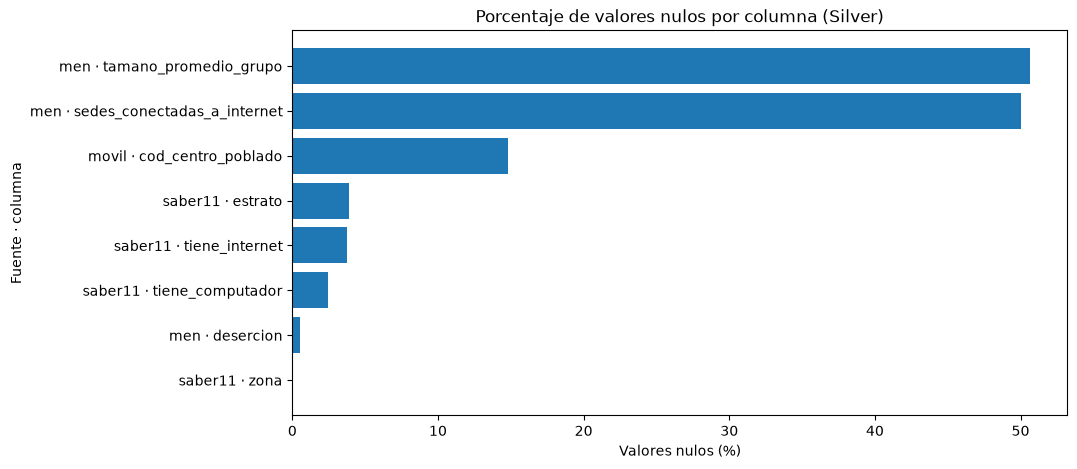

In [7]:
# Porcentaje de nulos de las columnas que tienen nulos
nulos = pd.concat([
    movil_df.isnull().mean() * 100,
    men_df.isnull().mean() * 100,
    saber_df.isnull().mean() * 100,
], keys=["movil", "men", "saber11"])
nulos = nulos[nulos > 0].sort_values()
print(nulos.round(2))

#Diagrama de barras horizontales del % de nulos por columna
plt.figure(figsize=(10, 5))
plt.barh([f"{fuente} · {columna}" for fuente, columna in nulos.index], nulos.values)
plt.xlabel("Valores nulos (%)")
plt.ylabel("Fuente · columna")
plt.title("Porcentaje de valores nulos por columna (Silver)")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "01_nulos_por_columna.png"), dpi=150, bbox_inches="tight")
plt.show()

Los nulos se concentran en pocas columnas y ninguno se imputó. En Saber 11 faltan `tiene_internet` (3,7 %), `tiene_computador` (2,4 %) y `estrato` (3,9 %): son estudiantes que no respondieron, y se excluyen al calcular porcentajes. En el MEN, `sedes_conectadas_a_internet` (50 %) solo tiene datos entre 2011 y 2017 en la propia fuente, y `tamano_promedio_grupo` tiene un vacío similar. Por eso no se usan en el índice. El 14,8 % de `cod_centro_poblado` son filas con código "0" ("sin centro poblado") que se convirtieron a nulo porque no identifican un lugar real. Los 3 nulos de deserción son de 2011, fuera de la ventana de análisis.

### 1.3 Duplicados

In [8]:
#Identificar duplicados según la llave natural de cada fuente.
# En internet fijo no hay identificador, así que se revisa la fila completa (ver la celda siguiente).
print("Internet fijo (fila completa):", internet_df.duplicated().sum())
print("Cobertura móvil (anio, trimestre, municipio, centro poblado, proveedor):",
      movil_df.duplicated(subset=["anio", "trimestre", "cod_mpio", "cod_centro_poblado", "centro_poblado", "proveedor"]).sum())
print("MEN (anio, cod_mpio):", men_df.duplicated(subset=["anio", "cod_mpio"]).sum())
print("Saber 11 (estu_consecutivo):", saber_df.duplicated(subset=["estu_consecutivo"]).sum())
print("Población (cod_mpio, anio, area):", poblacion_df.duplicated(subset=["cod_mpio", "anio", "area"]).sum())

Internet fijo (fila completa): 6855
Cobertura móvil (anio, trimestre, municipio, centro poblado, proveedor): 0
MEN (anio, cod_mpio): 0
Saber 11 (estu_consecutivo): 0
Población (cod_mpio, anio, area): 0


In [ ]:
# La limpieza elimina las filas idénticas en TODAS las columnas y después quita velocidad_subida.
internet_raw_df = pd.read_csv(os.path.join(PROJECT_ROOT, config["sources"]["internet_fijo"]["path"]), dtype=str)
print("Bronze - filas idénticas en todas las columnas:", internet_raw_df.duplicated().sum())

internet_raw_sin_dup = internet_raw_df.drop_duplicates()
print("Bronze después de eliminar esos duplicados:", internet_raw_sin_dup.duplicated().sum())

# Filas que solo se repiten si se ignora velocidad_subida (la columna que se elimina en Silver)
columnas_sin_subida = [c for c in internet_raw_sin_dup.columns if c != "velocidad_subida"]
print("Filas repetidas si se ignora velocidad_subida:", internet_raw_sin_dup.duplicated(subset=columnas_sin_subida).sum())
repetidas = internet_raw_sin_dup[internet_raw_sin_dup.duplicated(subset=columnas_sin_subida, keep=False)]
print("Grupos repetidos que tienen la misma velocidad_subida:",
      (repetidas.groupby(columnas_sin_subida)["velocidad_subida"].nunique() == 1).sum())
display(repetidas.sort_values(columnas_sin_subida).head(4))

# Efecto de los duplicados eliminados sobre los accesos del Valle en el T4 de 2022
t4_con_dup = internet_raw_df[(internet_raw_df["anno"] == "2022") & (internet_raw_df["trimestre"] == "4")]
t4_sin_dup = internet_raw_sin_dup[(internet_raw_sin_dup["anno"] == "2022") & (internet_raw_sin_dup["trimestre"] == "4")]
antes = pd.to_numeric(t4_con_dup["no_de_accesos"]).sum()
despues = pd.to_numeric(t4_sin_dup["no_de_accesos"]).sum()
print(f"Accesos T4 2022: {antes} con duplicados, {despues} sin duplicados, diferencia {(antes - despues) / antes * 100:.2f} %")

Bronze - filas idénticas en todas las columnas: 9116


Bronze después de eliminar esos duplicados: 0


Filas repetidas si se ignora velocidad_subida: 6855


Grupos repetidos que tienen la misma velocidad_subida: 0


,anno,trimestre,proveedor,cod_departamento,departamento,cod_municipio,municipio,segmento,tecnologia,velocidad_bajada,velocidad_subida,no_de_accesos
188748,2017,2,AXESS NETWORKS SOLUTIONS COLOMBIA SAS,76,VALLE DEL CAUCA,76109,BUENAVENTURA,CORPORATIVO,SATELITAL,"0,50","0,25",1
247620,2017,2,AXESS NETWORKS SOLUTIONS COLOMBIA SAS,76,VALLE DEL CAUCA,76109,BUENAVENTURA,CORPORATIVO,SATELITAL,"0,50","0,50",1
173827,2017,2,AXESS NETWORKS SOLUTIONS COLOMBIA SAS,76,VALLE DEL CAUCA,76111,GUADALAJARA DE BUGA,CORPORATIVO,SATELITAL,"0,50","0,50",1
193857,2017,2,AXESS NETWORKS SOLUTIONS COLOMBIA SAS,76,VALLE DEL CAUCA,76111,GUADALAJARA DE BUGA,CORPORATIVO,SATELITAL,"0,50","0,25",1


Accesos T4 2022: 918562 con duplicados, 915664 sin duplicados, diferencia 0.32 %


La sección anterior muestra 6.855 filas repetidas en `internet_fijo.csv`, pero no son duplicados reales. En Bronze había 9.116 filas idénticas en todas las columnas; la limpieza las elimina, y después de eso en Bronze queda 0. Luego, en Silver, se quita la columna `velocidad_subida` porque no se usa en el análisis. Las 6.855 filas que solo se diferenciaban en esa columna quedan iguales, y en ninguno de esos grupos coincide la velocidad de subida (0 grupos). Son planes distintos del mismo proveedor, así que se conservan y sus accesos se suman. Los 9.116 duplicados eliminados equivalen al 0,32 % de los accesos del T4 de 2022 (de 918.562 a 915.664).

### 1.4 Variables categóricas

In [10]:
# Zona del colegio en Saber 11
print(saber_df["zona"].nunique())
print(saber_df["zona"].value_counts())
print("--------------------------------------------------")
# Tenencia de internet y computador (1 = sí, 0 = no)
print(saber_df["tiene_internet"].value_counts())
print(saber_df["tiene_computador"].value_counts())
print("--------------------------------------------------")
# Segmentos de internet fijo
print(internet_df["segmento"].value_counts())

2
zona
urbano    261490
rural      33693
Name: count, dtype: int64
--------------------------------------------------
tiene_internet
1.0    198292
0.0     85855
Name: count, dtype: int64


tiene_computador
1.0    195078
0.0     92957
Name: count, dtype: int64
--------------------------------------------------
segmento
corporativo                        69176
residencial - estrato 2            57032
residencial - estrato 3            39094
residencial - estrato 1            35675
residencial - estrato 4            20981
residencial - estrato 5            13739
residencial - estrato 6             7203
sin estratificar                    3683
uso propio interno del operador      530
Name: count, dtype: int64


### 1.5 Cobertura de años y municipios por fuente

In [11]:
# Número de municipios con datos por año en cada fuente
cobertura = pd.DataFrame({
    "internet_fijo": internet_df.groupby("anio")["cod_mpio"].nunique(),
    "cobertura_movil": movil_df.groupby("anio")["cod_mpio"].nunique(),
    "men": men_df.groupby("anio")["cod_mpio"].nunique(),
    "saber11": saber_df.groupby("anio")["cod_mpio"].nunique(),
})
cobertura = cobertura.loc[2011:2024].fillna(0).astype(int)
print(cobertura)
print("--------------------------------------------------")
# Estudiantes y municipios por año y semestre en Saber 11
print(saber_df.groupby(["anio", "semestre"])["cod_mpio"].agg(["count", "nunique"]))
print("--------------------------------------------------")
# Último trimestre disponible por año en internet fijo
print(internet_df.groupby("anio")["trimestre"].max())
print("--------------------------------------------------")
# Centros poblados distintos reportados por año en cobertura móvil
print(movil_df.groupby("anio")["cod_centro_poblado"].nunique())

      internet_fijo  cobertura_movil  men  saber11
anio                                              
2011              0                0   42        0
2012              0                0   42        0
2013              0                0   42        0
2014              0                0   42       42
2015              0               42   42       42
2016              0               42   42       42
2017             42               42   42       42
2018             42               42   42       14
2019             42               42   42       42
2020             42               42   42       14
2021             42               42   42       12
2022             42               42   42       42
2023             42               42   42        0
2024              0                0   42        0
--------------------------------------------------


               count  nunique
anio semestre                
2014 2         41173       42
2015 1          8427       15
     2         39746       42
2016 1          6878       11
     2         40229       42
2017 1          6873       10
     2         38924       42
2018 1          7629       14
2019 1          6497       10
     4         38664       42
2020 1          6539       14
2021 1          7083       12
2022 1          7166       15
     4         39360       42
--------------------------------------------------
anio
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    3
Name: trimestre, dtype: int64
--------------------------------------------------
anio
2015    470
2016    470
2017    470
2018    471
2019    471
2020    531
2021    573
2022    236
2023    246
Name: cod_centro_poblado, dtype: int64


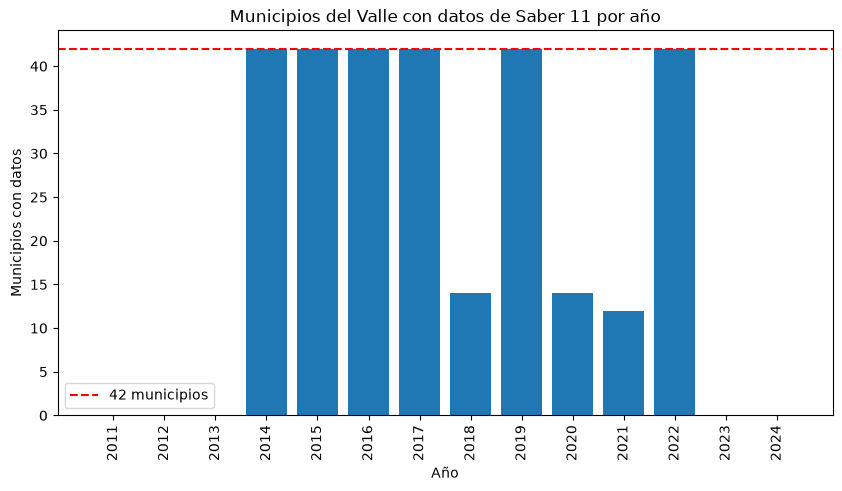

In [12]:
#Temporalidad: municipios con datos de Saber 11 por año
plt.figure(figsize=(10, 5))
plt.bar(cobertura.index, cobertura["saber11"])
plt.axhline(42, color="red", linestyle="--", label="42 municipios")
plt.xticks(cobertura.index, rotation=90)
plt.xlabel("Año")
plt.ylabel("Municipios con datos")
plt.title("Municipios del Valle con datos de Saber 11 por año")
plt.legend()
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "02_municipios_saber11_por_anio.png"), dpi=150, bbox_inches="tight")
plt.show()

La tabla muestra que el MEN y el DANE cubren los 42 municipios en todos los años. Internet fijo empieza en 2017 y cobertura móvil en 2015. Saber 11 tiene huecos: en 2018, 2020 y 2021 solo aparece el calendario A (12 a 14 municipios y entre 6.539 y 7.629 estudiantes), así que esos años se dejan nulos para no mezclar una muestra sesgada. Por eso la ventana común es 2017–2022: 2023 no tiene T4 de internet fijo (llega hasta el trimestre 3) ni resultados de Saber 11 publicados.

## 2. Estadística descriptiva (tabla integrada `municipio_anio`)

In [13]:
municipio_anio_df.info(verbose=True)
municipio_anio_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 22 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   cod_mpio                           252 non-null    str    
 1   municipio                          252 non-null    str    
 2   anio                               252 non-null    int64  
 3   poblacion_total                    252 non-null    int64  
 4   pct_poblacion_rural                252 non-null    float64
 5   trimestre_fijo                     252 non-null    int64  
 6   accesos_fijos_total                252 non-null    int64  
 7   accesos_fijos_residenciales        252 non-null    int64  
 8   accesos_por_100_hab                252 non-null    float64
 9   accesos_residenciales_por_100_hab  252 non-null    float64
 10  operadores_movil                   252 non-null    int64  
 11  operadores_4g                      252 non-null    int64  
 12  pct_c

,anio,poblacion_total,pct_poblacion_rural,trimestre_fijo,accesos_fijos_total,accesos_fijos_residenciales,accesos_por_100_hab,accesos_residenciales_por_100_hab,operadores_movil,operadores_4g,pct_centros_poblados_4g,cobertura_neta,cobertura_bruta,desercion,sedes_conectadas_a_internet,saber11_anio_completo,n_estudiantes_saber11,pct_estudiantes_con_internet,pct_estudiantes_con_computador,punt_global_prom
count,252.000000,2.520000e+02,252.000000,252.0,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,233.000000,252.000000,252.000000,252.000000,42.000000,252.000000,126.000000,126.000000,126.000000,126.000000
mean,2019.500000,1.084761e+05,36.764405,4.0,19493.230159,18098.718254,9.053413,8.156270,4.833333,3.178571,16.791888,78.758929,90.772659,4.905357,36.499762,0.500000,1091.142857,57.456905,49.094365,242.945952
std,1.711224,3.446763e+05,19.830478,0.0,78288.556817,72440.173024,6.918303,5.683866,0.760059,1.632543,28.263412,9.786700,11.382036,2.330209,21.124671,0.500995,3411.624858,18.260722,12.377227,13.269410
min,2017.000000,5.391000e+03,2.300000,4.0,34.000000,13.000000,0.390000,0.130000,3.000000,0.000000,0.000000,46.130000,54.230000,0.800000,2.330000,0.000000,51.000000,15.660000,18.670000,211.870000
25%,2018.000000,1.486225e+04,22.845000,4.0,596.250000,542.750000,4.277500,3.657500,4.000000,2.000000,0.000000,72.445000,84.185000,3.182500,22.930000,0.000000,141.250000,45.382500,40.492500,232.937500
50%,2019.500000,2.320950e+04,34.990000,4.0,1876.500000,1733.500000,8.120000,7.380000,5.000000,4.000000,0.000000,77.755000,88.655000,4.730000,30.500000,0.500000,233.500000,59.845000,48.075000,242.640000
75%,2021.000000,5.677925e+04,51.562500,4.0,6057.250000,5806.250000,12.080000,11.237500,5.000000,4.000000,22.220000,82.967500,95.932500,6.282500,44.442500,1.000000,633.750000,73.215000,57.650000,253.087500
max,2022.000000,2.283342e+06,82.200000,4.0,554244.000000,518002.000000,68.100000,24.650000,6.000000,6.000000,100.000000,111.060000,129.020000,15.210000,100.000000,1.000000,22481.000000,88.960000,77.800000,270.910000


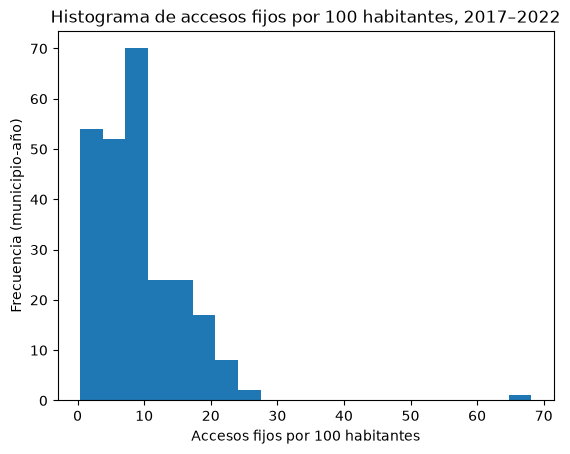

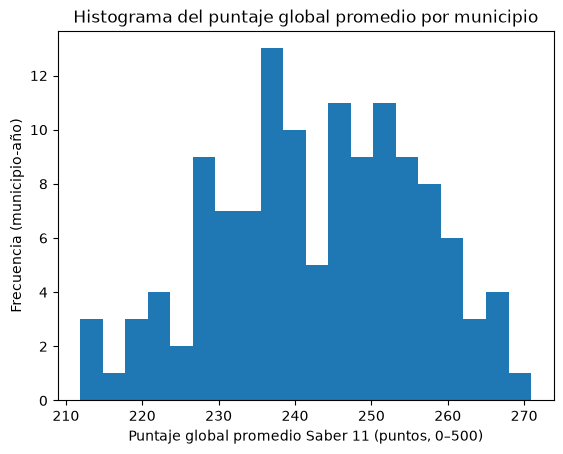

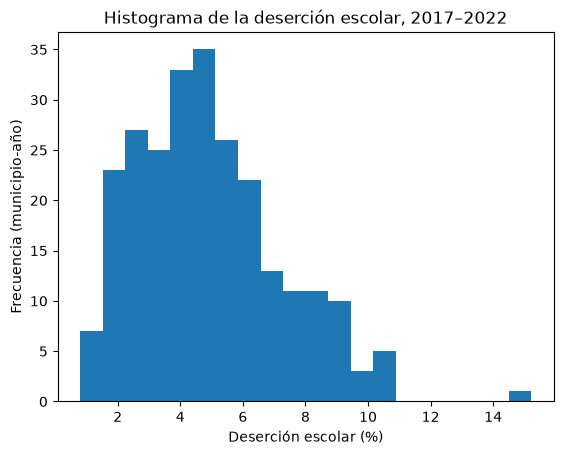

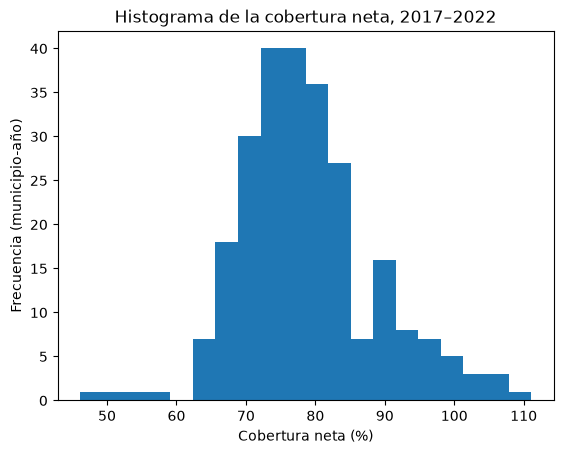

In [14]:
#Histograma de accesos fijos por 100 habitantes
plt.hist(municipio_anio_df["accesos_por_100_hab"], bins=20)
plt.xlabel("Accesos fijos por 100 habitantes")
plt.ylabel("Frecuencia (municipio-año)")
plt.title("Histograma de accesos fijos por 100 habitantes, 2017–2022")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "03_hist_accesos_por_100_hab.png"), dpi=150, bbox_inches="tight")
plt.show()

#Histograma del puntaje global promedio
plt.hist(municipio_anio_df["punt_global_prom"].dropna(), bins=20)
plt.xlabel("Puntaje global promedio Saber 11 (puntos, 0–500)")
plt.ylabel("Frecuencia (municipio-año)")
plt.title("Histograma del puntaje global promedio por municipio")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "04_hist_puntaje_global.png"), dpi=150, bbox_inches="tight")
plt.show()

#Histograma de la deserción
plt.hist(municipio_anio_df["desercion"], bins=20)
plt.xlabel("Deserción escolar (%)")
plt.ylabel("Frecuencia (municipio-año)")
plt.title("Histograma de la deserción escolar, 2017–2022")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "05_hist_desercion.png"), dpi=150, bbox_inches="tight")
plt.show()

#Histograma de la cobertura neta
plt.hist(municipio_anio_df["cobertura_neta"], bins=20)
plt.xlabel("Cobertura neta (%)")
plt.ylabel("Frecuencia (municipio-año)")
plt.title("Histograma de la cobertura neta, 2017–2022")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "06_hist_cobertura_neta.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Valor máximo de accesos por 100 habitantes
fila_max = municipio_anio_df.loc[municipio_anio_df["accesos_por_100_hab"].idxmax()]
print(fila_max[["municipio", "anio", "poblacion_total", "accesos_fijos_total", "accesos_por_100_hab"]])
print("--------------------------------------------------")
# Accesos por proveedor y segmento en ese municipio y año (T4)
detalle = internet_df[(internet_df["cod_mpio"] == fila_max["cod_mpio"]) & (internet_df["anio"] == fila_max["anio"]) & (internet_df["trimestre"] == 4)]
print(detalle.groupby(["proveedor", "segmento"])["accesos"].sum().sort_values(ascending=False).head(5))

municipio              ulloa
anio                    2017
poblacion_total         5433
accesos_fijos_total     3700
accesos_por_100_hab     68.1
Name: 216, dtype: object
--------------------------------------------------
proveedor                             segmento               
superredes sas                        corporativo                2242
                                      residencial - estrato 6    1121
insitel s.a.s.                        corporativo                 118
azteca comunicaciones colombia s.a.s  residencial - estrato 1     103
insitel s.a.s.                        sin estratificar             90
Name: accesos, dtype: int64


Los accesos por 100 habitantes tienen sesgo a la derecha (media 9,1 > mediana 8,1). El máximo de 68,1 es Ulloa en 2017: un solo proveedor (Superredes) reportó 2.242 accesos corporativos y 1.121 de estrato 6 en un municipio de 5.433 habitantes. Parece un error de reporte; se documenta pero no se elimina, y no afecta al ranking de 2022. El puntaje global es casi simétrico (212–271, media 243). La deserción también tiene sesgo a la derecha (media 4,9 %, máximo 15,2 %). La cobertura neta se concentra alrededor de 78 % (mediana 77,8), pero llega a 111 %. Una tasa neta mayor que 100 es un efecto del denominador (proyecciones de población con base en el Censo 2018), no un error de captura, así que se conserva y se documenta.

accesos_por_100_hab -> outliers: {}


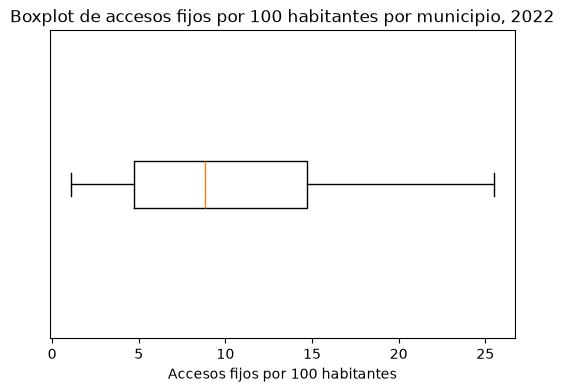

punt_global_prom -> outliers: {}


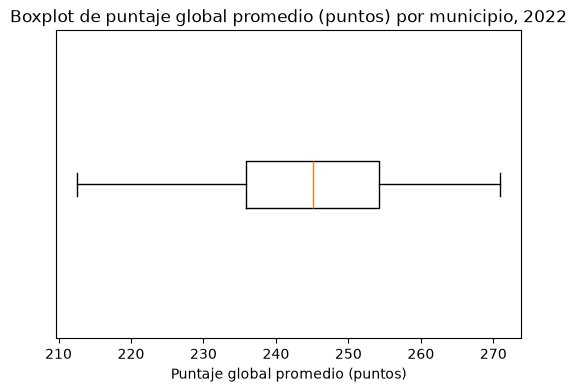

desercion -> outliers: {'alcalá': 9.92}


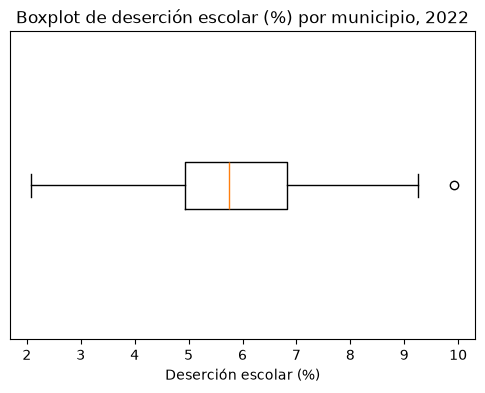

cobertura_neta -> outliers: {'yumbo': 99.87}


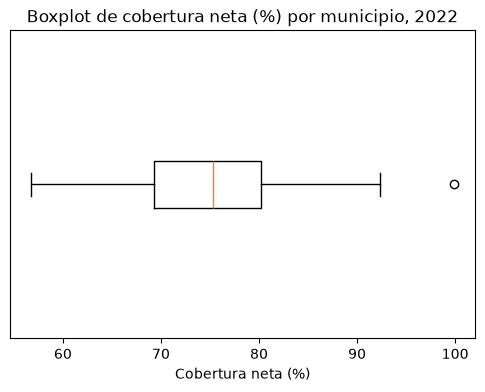

In [16]:
# Boxplots del último año para identificar outliers (regla de 1,5 x IQR)
ultimo_df = municipio_anio_df[municipio_anio_df["anio"] == anio]
columnas = {
    "accesos_por_100_hab": "Accesos fijos por 100 habitantes",
    "punt_global_prom": "Puntaje global promedio (puntos)",
    "desercion": "Deserción escolar (%)",
    "cobertura_neta": "Cobertura neta (%)",
}

# Un boxplot por variable, porque cada una tiene su propia escala
for columna, etiqueta in columnas.items():
    q1 = ultimo_df[columna].quantile(0.25)
    q3 = ultimo_df[columna].quantile(0.75)
    iqr = q3 - q1
    outliers = ultimo_df[(ultimo_df[columna] < q1 - 1.5 * iqr) | (ultimo_df[columna] > q3 + 1.5 * iqr)]
    print(columna, "-> outliers:", dict(zip(outliers["municipio"], outliers[columna])))

    plt.figure(figsize=(6, 4))
    plt.boxplot(ultimo_df[columna], orientation="horizontal")
    plt.yticks([])
    plt.xlabel(etiqueta)
    plt.title(f"Boxplot de {etiqueta.lower()} por municipio, {anio}")
    # Guardar la gráfica en reports/figures
    plt.savefig(os.path.join(FIGURES_DIR, f"07_boxplot_{columna}.png"), dpi=150, bbox_inches="tight")
    plt.show()

Con la regla de 1,5·IQR, en 2022 no hay outliers en accesos por 100 habitantes ni en puntaje. Al usar tasas, Cali (23,97 en la tabla de P2) deja de ser atípica: solo lo es en valores absolutos, por su tamaño. Aparecen como outliers Alcalá en deserción (9,9 %) y Yumbo en cobertura neta (99,9 %). Son valores reales de la fuente, así que se mantienen: eliminarlos borraría justo los casos que interesan al usuario.

## 3. P1 – Brecha urbano-rural en acceso a internet

hogares de estudiantes de grado 11 según la zona del colegio (no de la vivienda).
Solo años completos de Saber 11: 2014, 2015, 2016, 2017, 2019 y 2022.
2014 solo incluye calendario B (en el periodo 20141 no existe el puntaje global); los demás años incluyen calendario A y B.>

zona  rural  urbano  brecha_pp
anio                          
2014   24.5    56.8       32.3
2015   32.0    65.1       33.1
2016   34.9    67.3       32.5
2017   45.0    73.9       28.9
2019   51.6    78.6       26.9
2022   70.9    85.1       14.2

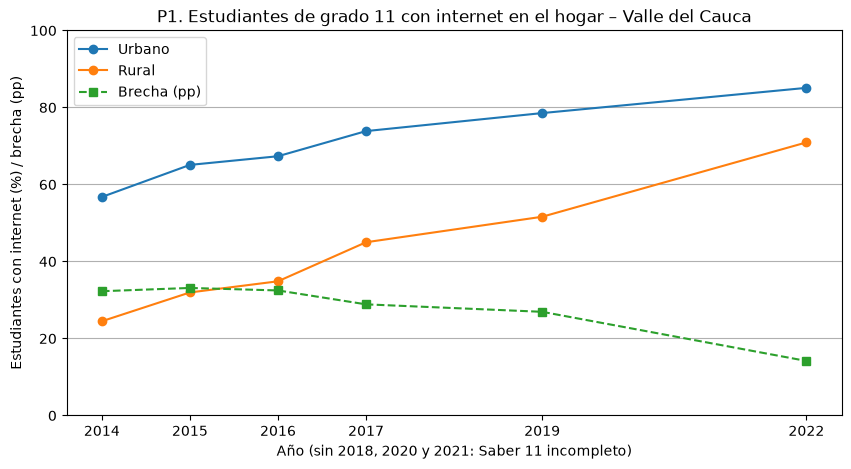

In [ ]:
# Agregado del Valle: % de estudiantes con internet por año y zona
valle_df = brecha_df[brecha_df["nivel"] == "departamento"]
valle_df = valle_df.pivot(index="anio", columns="zona", values="pct_con_internet")
valle_df["brecha_pp"] = valle_df["urbano"] - valle_df["rural"]
print(valle_df.round(1))

#Temporalidad: evolución urbano vs rural
plt.figure(figsize=(10, 5))
plt.plot(valle_df.index, valle_df["urbano"], marker="o", label="Urbano")
plt.plot(valle_df.index, valle_df["rural"], marker="o", label="Rural")
plt.plot(valle_df.index, valle_df["brecha_pp"], marker="s", linestyle="--", label="Brecha (pp)")
plt.xticks(valle_df.index)
plt.ylim(0, 100)
plt.xlabel("Año (sin 2018, 2020 y 2021: Saber 11 incompleto)")
plt.ylabel("Estudiantes con internet (%) / brecha (pp)")
plt.title("P1. Estudiantes de grado 11 con internet en el hogar – Valle del Cauca")
plt.legend()
plt.grid(axis="y")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "08_p1_evolucion_urbano_rural.png"), dpi=150, bbox_inches="tight")
plt.show()

La brecha urbano-rural en acceso a internet se redujo a menos de la mitad, pasó de 32,3 puntos porcentuales en 2014 a 14,2 pp en 2022. El acceso rural pasó de 24,5 % a 70,9 % y el urbano de 56,8 % a 85,1 %. La mayor reducción ocurre entre 2019 y 2022 (de 26,9 a 14,2 pp), un periodo que coincide con la pandemia, aunque este análisis no prueba esa causa. Recordar que es una aproximación: son hogares de estudiantes de grado 11 y la zona es la del colegio.

Municipios con muestra suficiente en ambas zonas: 32 de 42
Excluidos: ['argelia', 'calima', 'el cairo', 'el dovio', 'la unión', 'obando', 'pradera', 'toro', 'ulloa', 'versalles']
          municipio  urbano  rural  n_rural  brecha_pp
         candelaria   82.92  87.52      582      -4.60
            guacarí   64.63  67.96      110      -3.33
         el cerrito   75.62  78.57      254      -2.95
          la cumbre   64.91  66.04       58      -1.13
             zarzal   80.99  80.25       90       0.74
             alcalá   58.82  56.04      100       2.78
              yumbo   89.62  85.93      279       3.69
               cali   89.12  85.23      914       3.89
            ginebra   86.80  80.61      107       6.19
        la victoria   63.00  56.25       32       6.75
            palmira   89.30  82.13      487       7.17
            florida   73.71  64.49      120       9.22
         roldanillo   84.60  73.02       72      11.58
            riofrío   67.50  53.98      120      13

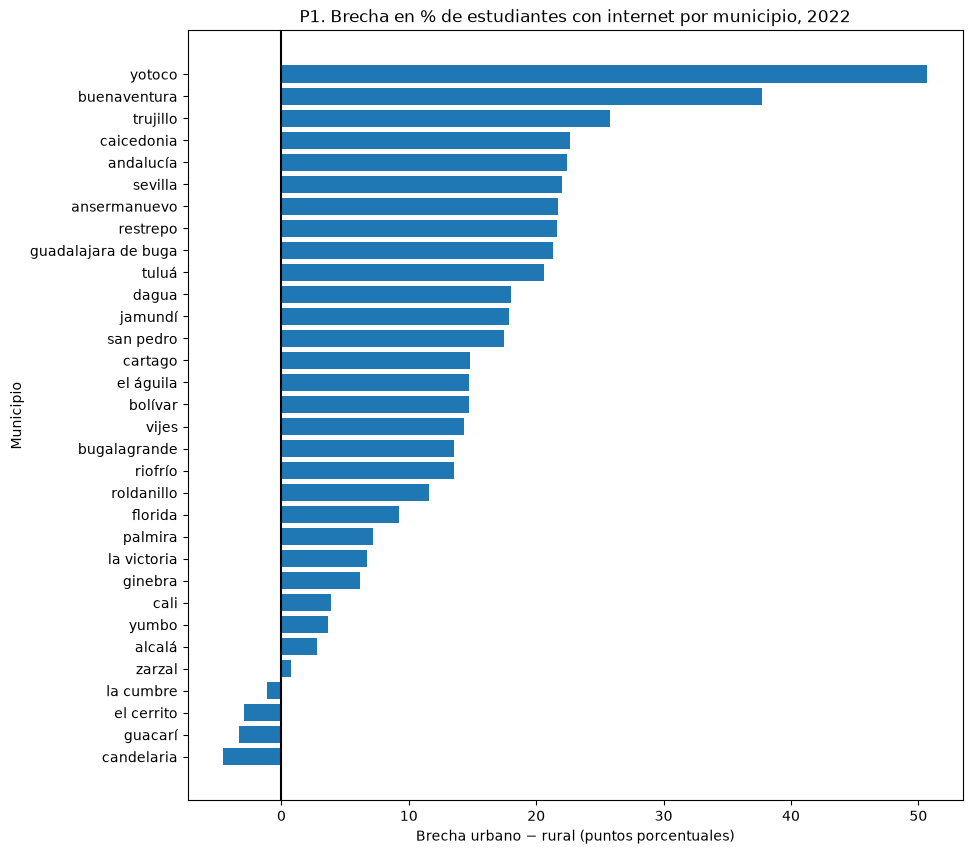

In [ ]:
# Brecha por municipio en el último año: solo municipios con >= 30 estudiantes en cada zona
municipal_df = brecha_df[(brecha_df["nivel"] == "municipio") & (brecha_df["anio"] == anio) & (brecha_df["muestra_suficiente"] == 1)]
tabla_df = municipal_df.pivot(index="cod_mpio", columns="zona", values="pct_con_internet").dropna()
tabla_df["brecha_pp"] = tabla_df["urbano"] - tabla_df["rural"]
tabla_df = tabla_df.merge(dim_df, left_index=True, right_on="cod_mpio").sort_values("brecha_pp")
print("Municipios con muestra suficiente en ambas zonas:", len(tabla_df), "de 42")
print("Excluidos:", sorted(set(dim_df["municipio"]) - set(tabla_df["municipio"])))

# Estudiantes rurales por municipio, para saber qué tan confiable es cada brecha
n_rural = municipal_df[municipal_df["zona"] == "rural"].set_index("cod_mpio")["n_estudiantes"]
tabla_df["n_rural"] = tabla_df["cod_mpio"].map(n_rural)
print(tabla_df[["municipio", "urbano", "rural", "n_rural", "brecha_pp"]].round(2).to_string(index=False))
print("Mediana de la brecha:", round(tabla_df["brecha_pp"].median(), 2))
print("Municipios con brecha negativa:", tabla_df[tabla_df["brecha_pp"] < 0]["municipio"].tolist())

#Diagrama de barras horizontales de la brecha por municipio
plt.figure(figsize=(10, 10))
plt.barh(tabla_df["municipio"], tabla_df["brecha_pp"])
plt.axvline(0, color="black")
plt.xlabel("Brecha urbano − rural (puntos porcentuales)")
plt.ylabel("Municipio")
plt.title(f"P1. Brecha en % de estudiantes con internet por municipio, {anio}")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "09_p1_brecha_por_municipio.png"), dpi=150, bbox_inches="tight")
plt.show()

Solo 32 de los 42 municipios tienen al menos 30 estudiantes en ambas zonas. Los otros 10 no se grafican porque su porcentaje no es confiable. La mediana de la brecha es de 14,5 pp. Las más grandes están en Yotoco (50,7 pp, aunque con solo 35 estudiantes rurales, así que hay que leerlo con cautela), Buenaventura (37,7 pp, con 383 estudiantes rurales, un resultado robusto) y Trujillo (25,8 pp). En 4 municipios (Candelaria, Guacarí, El Cerrito y La Cumbre) los colegios rurales tienen incluso más acceso que los urbanos.

## 4. P2 – Municipios con menores niveles de conectividad

     municipio  accesos_residenciales_por_100_hab  accesos_por_100_hab
89   el águila                               0.86                 1.08
179    riofrío                               1.05                 1.20
95    el cairo                               1.22                 1.43
233      vijes                               2.06                 2.38
227  versalles                               2.79                 3.10
35     bolívar                               2.80                 3.00
221      ulloa                               2.90                 3.03
209   trujillo                               2.95                 3.36
29     argelia                               2.96                 3.09
107   el dovio                               3.90                 4.52
--------------------------------------------------
    municipio  accesos_residenciales_por_100_hab  accesos_por_100_hab
161   palmira                              21.01                22.26
5        cali               

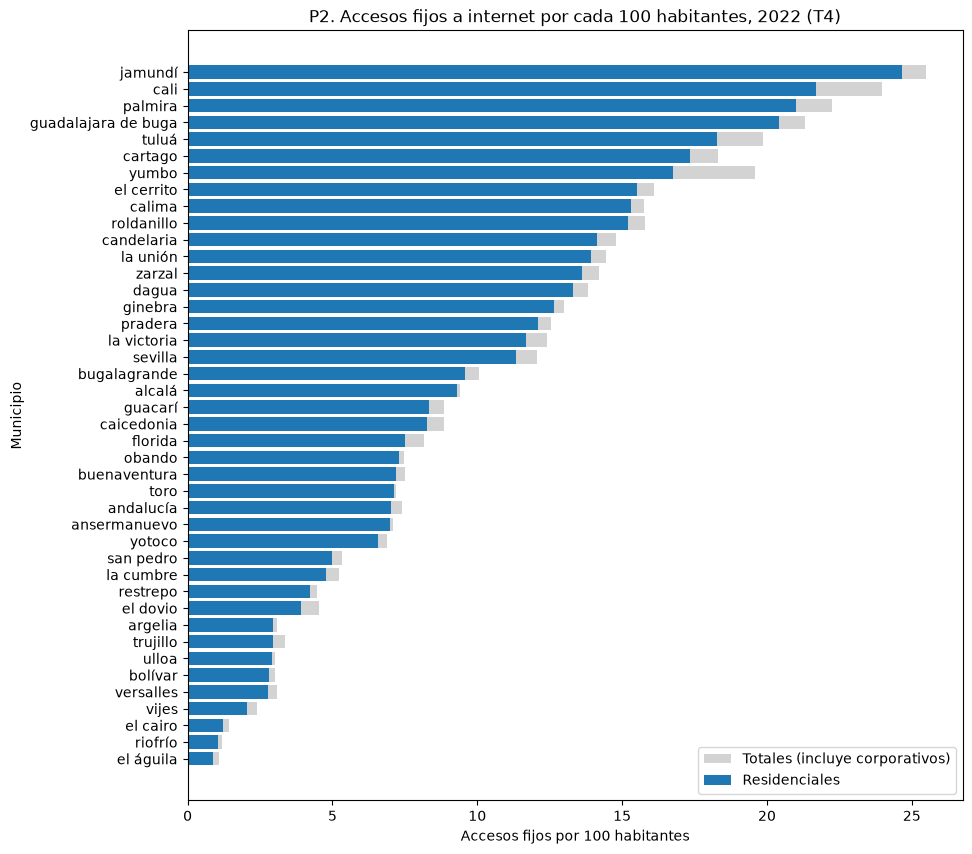

In [19]:
# Ranking de accesos fijos por 100 habitantes en el último año
datos_df = ultimo_df.sort_values("accesos_residenciales_por_100_hab")
print(datos_df[["municipio", "accesos_residenciales_por_100_hab", "accesos_por_100_hab"]].head(10))
print("--------------------------------------------------")
print(datos_df[["municipio", "accesos_residenciales_por_100_hab", "accesos_por_100_hab"]].tail(3))
print("Máximo / mínimo de accesos residenciales:",
      round(datos_df["accesos_residenciales_por_100_hab"].max() / datos_df["accesos_residenciales_por_100_hab"].min(), 1))

#Diagrama de barras horizontales: residenciales vs totales
plt.figure(figsize=(10, 10))
plt.barh(datos_df["municipio"], datos_df["accesos_por_100_hab"], color="lightgray", label="Totales (incluye corporativos)")
plt.barh(datos_df["municipio"], datos_df["accesos_residenciales_por_100_hab"], label="Residenciales")
plt.xlabel("Accesos fijos por 100 habitantes")
plt.ylabel("Municipio")
plt.title(f"P2. Accesos fijos a internet por cada 100 habitantes, {anio} (T4)")
plt.legend()
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "10_p2_accesos_por_100_hab.png"), dpi=150, bbox_inches="tight")
plt.show()

En 2022 los municipios con menos accesos fijos residenciales por 100 habitantes son El Águila (0,86), Riofrío (1,05), El Cairo (1,22), Vijes (2,06), Versalles, Bolívar, Ulloa, Trujillo y Argelia (entre 2,8 y 3,0). Todos son municipios pequeños y de montaña. En el otro extremo están Jamundí (24,6), Cali (21,7) y Palmira (21,0); Jamundí tiene **28,7 veces más** que El Águila. En casi todos los municipios la barra gris (total) apenas sobresale de la azul (residencial), así que los accesos corporativos no cambian el orden. Nota: en municipios rurales muchos hogares se reportan como "sin estratificar", y ese segmento se contó como residencial (ver README).

operadores_4g
4    39
3     3
Name: count, dtype: int64
Municipios con menos de 4 operadores 4G: ['bolívar', 'el dovio', 'la victoria']


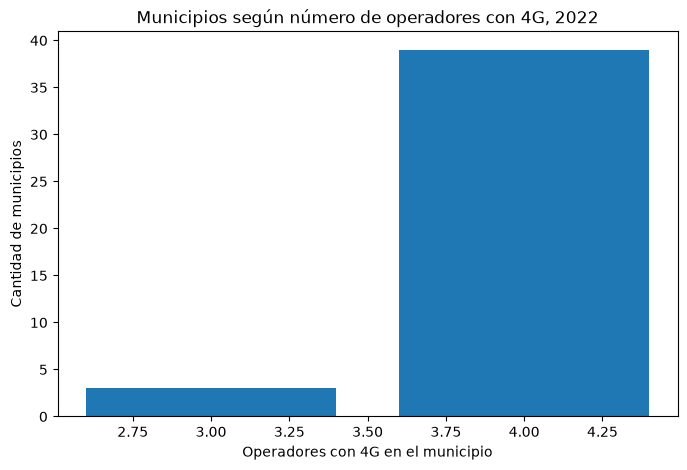

      mean  max
anio           
2017  1.64    5
2018  2.74    5
2019  3.00    5
2020  3.21    5
2021  4.55    6
2022  3.93    4


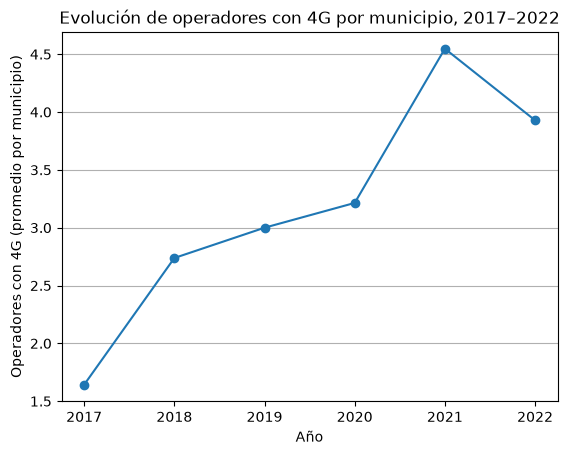

In [20]:
# Operadores con 4G por municipio en el último año
print(ultimo_df["operadores_4g"].value_counts())
print("Municipios con menos de 4 operadores 4G:", ultimo_df[ultimo_df["operadores_4g"] < 4]["municipio"].tolist())

#Diagrama de barras: cantidad de municipios según operadores con 4G
plt.figure(figsize=(8, 5))
plt.bar(ultimo_df["operadores_4g"].value_counts().index, ultimo_df["operadores_4g"].value_counts().values)
plt.xlabel("Operadores con 4G en el municipio")
plt.ylabel("Cantidad de municipios")
plt.title(f"Municipios según número de operadores con 4G, {anio}")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "11_p2_operadores_4g_municipios.png"), dpi=150, bbox_inches="tight")
plt.show()

#Temporalidad: promedio de operadores con 4G por año
print(municipio_anio_df.groupby("anio")["operadores_4g"].agg(["mean", "max"]).round(2))
promedio_4g = municipio_anio_df.groupby("anio")["operadores_4g"].mean()
plt.plot(promedio_4g.index, promedio_4g.values, marker="o")
plt.xlabel("Año")
plt.ylabel("Operadores con 4G (promedio por municipio)")
plt.title("Evolución de operadores con 4G por municipio, 2017–2022")
plt.grid(axis="y")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "12_p2_evolucion_operadores_4g.png"), dpi=150, bbox_inches="tight")
plt.show()

El promedio de operadores con 4G por municipio pasó de 1,6 (2017) a 3,9 (2022). En 2022 todos los municipios tienen entre 3 y 4 operadores con 4G en alguna parte de su territorio, y solo Bolívar, El Dovio y La Victoria tienen 3. Es decir, a nivel municipal la cobertura 4G ya casi no distingue a unos municipios de otros: la diferencia real está en el acceso fijo de los hogares. El máximo de 6 operadores en 2021 y la caída a 4 en 2022 coinciden con el cambio en la forma de reporte del dataset: los centros poblados reportados pasan de 573 en 2021 a 236 en 2022 (sección 1.5). Además, cobertura no es uso ni calidad.

## 5. P3 – Computador e internet en hogares rurales

> Microdatos Saber 11 (Silver) del último año, solo estudiantes con respuesta en ambas preguntas.

In [21]:
saber_anio_df = saber_df[saber_df["anio"] == anio].dropna(subset=["zona", "tiene_computador", "tiene_internet"])

# Tabla cruzada: % con internet según zona y tenencia de computador
cruzada = pd.crosstab([saber_anio_df["zona"], saber_anio_df["tiene_computador"]], saber_anio_df["tiene_internet"], normalize="index") * 100
print(cruzada.round(1))
print("--------------------------------------------------")
print(pd.crosstab([saber_anio_df["zona"], saber_anio_df["tiene_computador"]], saber_anio_df["tiene_internet"], margins=True))

# Correlación computador-internet en rurales
rural_df = saber_anio_df[saber_anio_df["zona"] == "rural"]
print("Correlación computador-internet en rurales:", round(rural_df["tiene_computador"].corr(rural_df["tiene_internet"]), 3))

tiene_internet            0.0   1.0
zona   tiene_computador            
rural  0.0               45.2  54.8
       1.0                9.4  90.6
urbano 0.0               32.9  67.1
       1.0                4.5  95.5
--------------------------------------------------
tiene_internet            0.0    1.0    All
zona   tiene_computador                    
rural  0.0               1336   1618   2954
       1.0                228   2194   2422
urbano 0.0               4428   9016  13444
       1.0               1049  22303  23352
All                      7041  35131  42172
Correlación computador-internet en rurales: 0.392


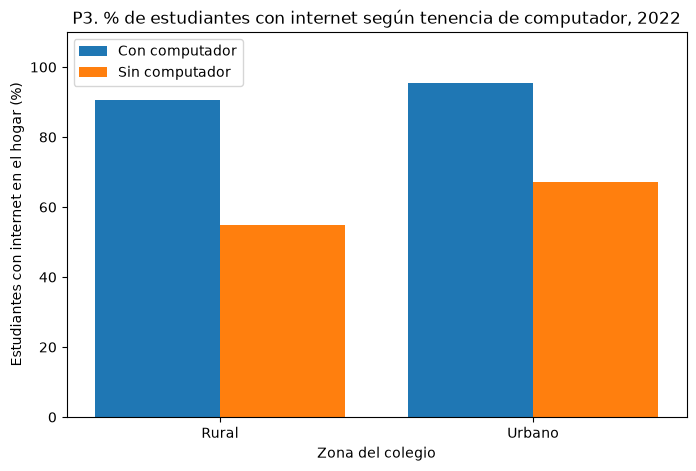

In [22]:
#Diagrama de barras agrupadas: % con internet según computador, rural vs urbano
con_pc = [cruzada.loc[("rural", 1), 1], cruzada.loc[("urbano", 1), 1]]
sin_pc = [cruzada.loc[("rural", 0), 1], cruzada.loc[("urbano", 0), 1]]
x = np.arange(2)

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, con_pc, width=0.4, label="Con computador")
plt.bar(x + 0.2, sin_pc, width=0.4, label="Sin computador")
plt.xticks(x, ["Rural", "Urbano"])
plt.ylim(0, 110)
plt.xlabel("Zona del colegio")
plt.ylabel("Estudiantes con internet en el hogar (%)")
plt.title(f"P3. % de estudiantes con internet según tenencia de computador, {anio}")
plt.legend()
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "13_p3_internet_segun_computador.png"), dpi=150, bbox_inches="tight")
plt.show()

En los colegios rurales, el **90,6 %** de los estudiantes con computador tiene internet, frente al **54,8 %** de los que no tienen computador. En los urbanos, las cifras son 95,5 % y 67,1 %. En el grupo rural, la asociación computador-internet es positiva y moderada (phi = 0,39). Aun así, más de la mitad de los estudiantes rurales sin computador ya tiene internet, probablemente a través del celular. Es una asociación, no una relación causal.

      pct_con_computador  pct_internet_si_tiene_pc  \
anio                                                 
2014               43.08                     50.00   
2015               44.37                     66.01   
2016               46.49                     65.65   
2017               50.54                     70.44   
2019               46.80                     77.60   
2022               44.61                     90.59   

      pct_internet_si_no_tiene_pc  
anio                               
2014                         5.16  
2015                         4.79  
2016                         8.12  
2017                        18.56  
2019                        28.30  
2022                        54.77  


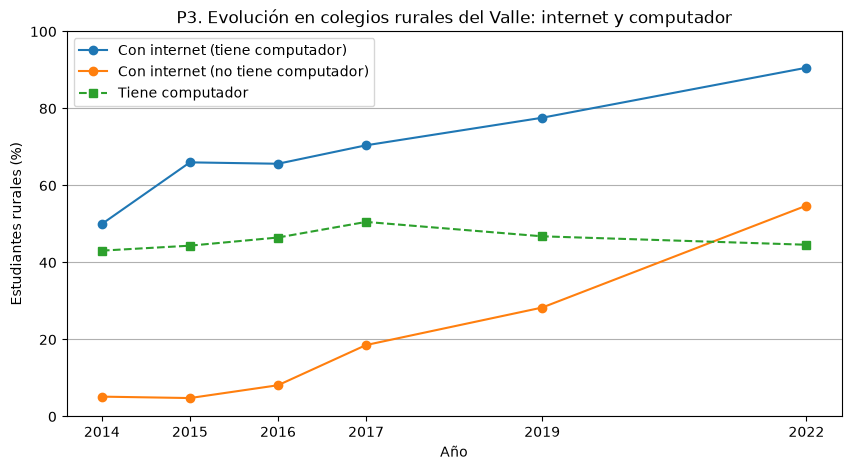

In [23]:
# Evolución en colegios rurales del Valle
rural_valle_df = brecha_df[(brecha_df["nivel"] == "departamento") & (brecha_df["zona"] == "rural")].set_index("anio")
print(rural_valle_df[["pct_con_computador", "pct_internet_si_tiene_pc", "pct_internet_si_no_tiene_pc"]])

#Temporalidad
plt.figure(figsize=(10, 5))
plt.plot(rural_valle_df.index, rural_valle_df["pct_internet_si_tiene_pc"], marker="o", label="Con internet (tiene computador)")
plt.plot(rural_valle_df.index, rural_valle_df["pct_internet_si_no_tiene_pc"], marker="o", label="Con internet (no tiene computador)")
plt.plot(rural_valle_df.index, rural_valle_df["pct_con_computador"], marker="s", linestyle="--", label="Tiene computador")
plt.xticks(rural_valle_df.index)
plt.ylim(0, 100)
plt.xlabel("Año")
plt.ylabel("Estudiantes rurales (%)")
plt.title("P3. Evolución en colegios rurales del Valle: internet y computador")
plt.legend()
plt.grid(axis="y")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "14_p3_evolucion_rural.png"), dpi=150, bbox_inches="tight")
plt.show()

En la zona rural, el internet entre quienes no tienen computador pasó de 5,2 % (2014) a **54,8 % (2022)**, mientras que el porcentaje con computador se mantuvo casi plano (entre 43 % y 51 %). El acceso a internet creció desligado del computador, y hoy la brecha principal en lo rural es de dispositivos, solo el 44,6 % de los estudiantes rurales tiene computador.

## 6. P4 – Conectividad del municipio vs. indicadores educativos

> **Correlación no implica causalidad.** Los municipios con más conectividad también son más urbanos.

Puntaje:   Pearson r = 0.57, Spearman = 0.56
Deserción: Pearson r = -0.22, Spearman = -0.20


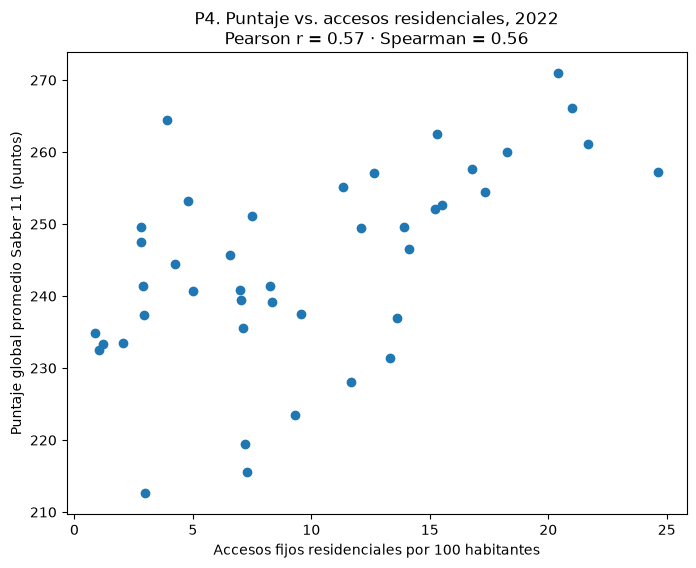

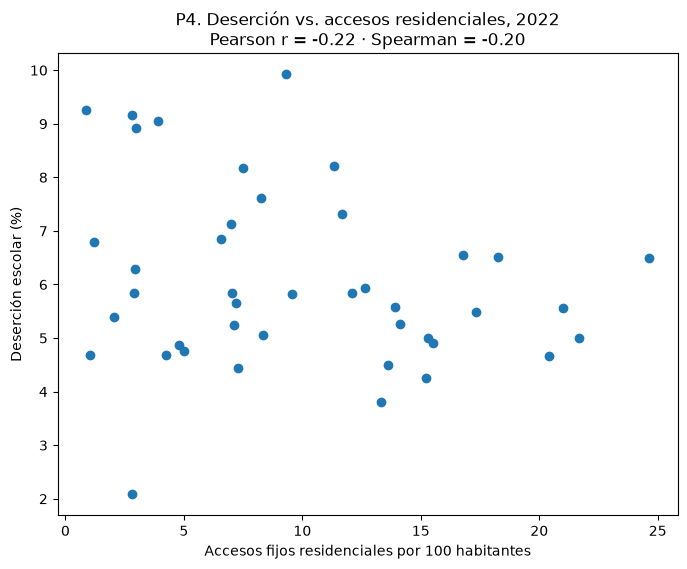

In [24]:
# Correlaciones de Pearson y Spearman (Spearman = Pearson sobre los rangos)
x = ultimo_df["accesos_residenciales_por_100_hab"]
r_puntaje = x.corr(ultimo_df["punt_global_prom"])
rho_puntaje = x.rank().corr(ultimo_df["punt_global_prom"].rank())
r_desercion = x.corr(ultimo_df["desercion"])
rho_desercion = x.rank().corr(ultimo_df["desercion"].rank())
print(f"Puntaje:   Pearson r = {r_puntaje:.2f}, Spearman = {rho_puntaje:.2f}")
print(f"Deserción: Pearson r = {r_desercion:.2f}, Spearman = {rho_desercion:.2f}")

#Diagrama de dispersión: accesos vs puntaje
plt.figure(figsize=(8, 6))
plt.scatter(x, ultimo_df["punt_global_prom"])
plt.xlabel("Accesos fijos residenciales por 100 habitantes")
plt.ylabel("Puntaje global promedio Saber 11 (puntos)")
plt.title(f"P4. Puntaje vs. accesos residenciales, {anio}\nPearson r = {r_puntaje:.2f} · Spearman = {rho_puntaje:.2f}")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "15_p4_dispersion_puntaje.png"), dpi=150, bbox_inches="tight")
plt.show()

#Diagrama de dispersión: accesos vs deserción
plt.figure(figsize=(8, 6))
plt.scatter(x, ultimo_df["desercion"])
plt.xlabel("Accesos fijos residenciales por 100 habitantes")
plt.ylabel("Deserción escolar (%)")
plt.title(f"P4. Deserción vs. accesos residenciales, {anio}\nPearson r = {r_desercion:.2f} · Spearman = {rho_desercion:.2f}")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "16_p4_dispersion_desercion.png"), dpi=150, bbox_inches="tight")
plt.show()

En 2022 hay una correlación positiva y moderada entre los accesos fijos residenciales por 100 habitantes y el puntaje global promedio (**r = 0,57**, Spearman ρ = 0,56). Con la deserción la correlación es débil y negativa (r = −0,22). Correlación no implica causalidad, los municipios más conectados también son más urbanos (r = −0,54 con el % de población rural), y la urbanización puede explicar a la vez la conectividad y el puntaje.

In [25]:
# Tabla de correlaciones entre variables del último año
columnas = ["accesos_residenciales_por_100_hab", "operadores_4g", "pct_estudiantes_con_internet",
            "punt_global_prom", "cobertura_neta", "desercion", "pct_poblacion_rural"]
print(ultimo_df[columnas].corr().round(2))
print("--------------------------------------------------")
# ¿Se mantiene la relación en los años con Saber 11 completo?
for a in [2017, 2019, 2022]:
    datos_anio = municipio_anio_df[municipio_anio_df["anio"] == a]
    print(a, "correlación de accesos residenciales con puntaje:",
          round(datos_anio["accesos_residenciales_por_100_hab"].corr(datos_anio["punt_global_prom"]), 2),
          "| con operadores_4g:",
          round(datos_anio["accesos_residenciales_por_100_hab"].corr(datos_anio["operadores_4g"]), 2))

                                   accesos_residenciales_por_100_hab  \
accesos_residenciales_por_100_hab                               1.00   
operadores_4g                                                   0.16   
pct_estudiantes_con_internet                                    0.74   
punt_global_prom                                                0.57   
cobertura_neta                                                  0.38   
desercion                                                      -0.22   
pct_poblacion_rural                                            -0.54   

                                   operadores_4g  \
accesos_residenciales_por_100_hab           0.16   
operadores_4g                               1.00   
pct_estudiantes_con_internet                0.22   
punt_global_prom                           -0.06   
cobertura_neta                             -0.23   
desercion                                  -0.41   
pct_poblacion_rural                        -0.10   

      

En la tabla de correlaciones, los accesos residenciales correlacionan fuerte con el % de estudiantes con internet en casa (0,74), lo que valida que las dos fuentes (MinTIC e ICFES) miden algo coherente. La relación con el puntaje se repite en los tres años completos (r = 0,44 en 2017, 0,63 en 2019 y 0,57 en 2022). En cambio, la correlación con operadores 4G cae a 0,16 en 2022 (era 0,82 en 2019) porque esa variable ya casi no varía entre municipios.

                  count   mean   std    min    25%    50%    75%    max
tiene_internet                                                         
0.0              7249.0  232.5  46.3  138.0  196.0  227.0  263.0  409.0
1.0             36139.0  261.3  51.7   27.0  222.0  260.0  299.0  450.0
--------------------------------------------------
estrato
0.0      937
1.0    10423
2.0    16208
3.0    10390
4.0     2916
5.0     1405
6.0      657
Name: count, dtype: int64


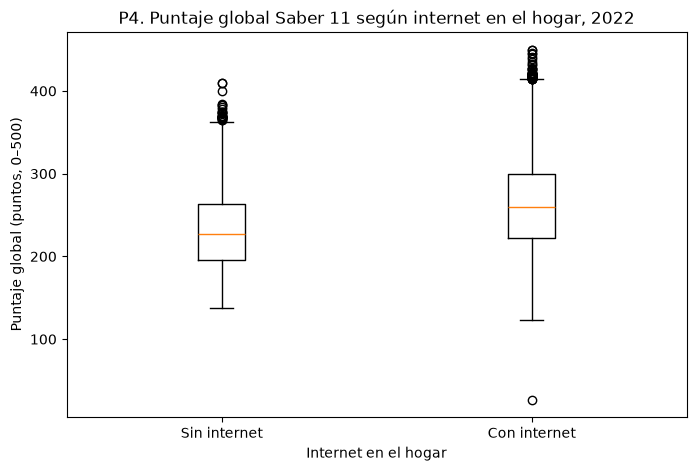

tiene_internet    0.0    1.0  diferencia
estrato                                 
0.0             209.3  230.1        20.8
1.0             233.2  248.6        15.4
2.0             238.6  258.9        20.3
3.0             231.2  265.1        33.9
4.0             217.4  276.2        58.9
5.0             209.3  296.0        86.7
6.0             199.1  299.6       100.5


In [26]:
# Puntaje global según internet en el hogar (microdatos del último año)
saber_internet_df = saber_df[(saber_df["anio"] == anio) & saber_df["tiene_internet"].notna()]
print(saber_internet_df.groupby("tiene_internet")["punt_global"].describe().round(1))
print("--------------------------------------------------")
# Estudiantes por estrato (0 = sin estrato)
print(saber_internet_df["estrato"].value_counts().sort_index())

#Boxplot del puntaje según internet sí/no
plt.figure(figsize=(8, 5))
plt.boxplot([saber_internet_df[saber_internet_df["tiene_internet"] == 0]["punt_global"],
             saber_internet_df[saber_internet_df["tiene_internet"] == 1]["punt_global"]])
plt.xticks([1, 2], ["Sin internet", "Con internet"])
plt.xlabel("Internet en el hogar")
plt.ylabel("Puntaje global (puntos, 0–500)")
plt.title(f"P4. Puntaje global Saber 11 según internet en el hogar, {anio}")
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "17_p4_boxplot_puntaje_internet.png"), dpi=150, bbox_inches="tight")
plt.show()

# Diferencia de medias por estrato (con − sin internet)
por_estrato = saber_internet_df.groupby(["estrato", "tiene_internet"])["punt_global"].mean().unstack()
por_estrato["diferencia"] = por_estrato[1] - por_estrato[0]
print(por_estrato.round(1))

Los estudiantes con internet en casa obtienen en promedio **261,3 puntos**, frente a **232,5** de quienes no lo tienen. Pero la diferencia crece con el estrato: es de 15 puntos en estrato 1, 20 en estrato 2 y 100 en estrato 6, donde los estudiantes sin internet son muy pocos y atípicos. Parte de la brecha es socioeconómica. En los estratos 1 y 2, que concentran la mayoría de estudiantes (ver el conteo por estrato), la diferencia es de 15 a 20 puntos.

## 7. P5 – Índice de priorización

Supuestos (ver README): normalización min-max (0–1), deserción invertida, **pesos iguales**, niveles por terciles.
Posición 1 = índice más bajo = **mayor prioridad**.

Municipios con mejor situación (índice más alto):
              municipio  indice
37              jamundí  0.7645
38                yumbo  0.8112
39              palmira  0.8152
40                 cali  0.8191
41  guadalajara de buga  0.8312


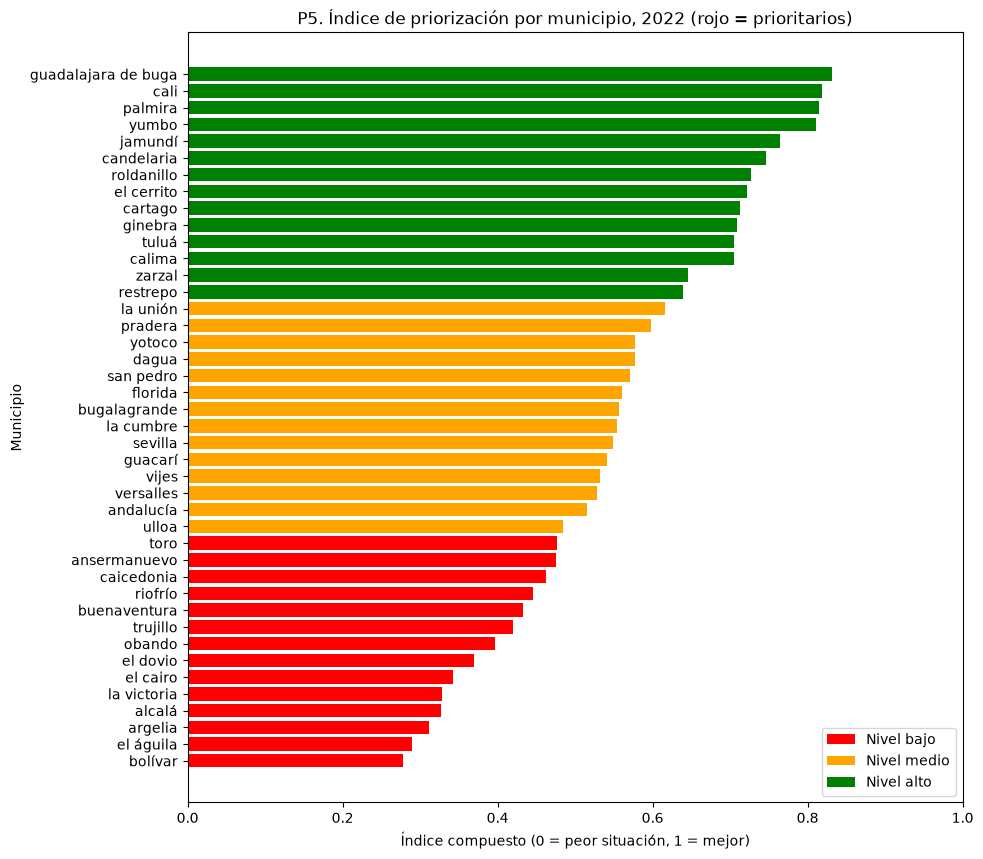

In [27]:
# Ranking del índice coloreado por nivel
datos_df = ranking_df.sort_values("indice")
print("Municipios con mejor situación (índice más alto):")
print(datos_df[["municipio", "indice"]].tail(5))

#Diagrama de barras horizontales (un color por nivel)
plt.figure(figsize=(10, 10))
for nivel, color in [("bajo", "red"), ("medio", "orange"), ("alto", "green")]:
    grupo = datos_df[datos_df["nivel"] == nivel]
    plt.barh(grupo["municipio"], grupo["indice"], color=color, label=f"Nivel {nivel}")
plt.xlim(0, 1)
plt.xlabel("Índice compuesto (0 = peor situación, 1 = mejor)")
plt.ylabel("Municipio")
plt.title(f"P5. Índice de priorización por municipio, {anio} (rojo = prioritarios)")
plt.legend()
# Guardar la gráfica en reports/figures
plt.savefig(os.path.join(FIGURES_DIR, "18_p5_ranking_indice.png"), dpi=150, bbox_inches="tight")
plt.show()

Los 14 municipios prioritarios (tercil bajo del índice en 2022) son: Bolívar, El Águila, Argelia, Alcalá, La Victoria, El Cairo, El Dovio, Obando, Trujillo, Buenaventura, Riofrío, Caicedonia, Ansermanuevo y Toro. Casi todos son municipios pequeños del norte del Valle o de la cordillera. La excepción es Buenaventura, municipio grande y costero; en la tabla siguiente se ve por qué queda en este grupo. Los que están en mejor situación son Buga, Cali, Palmira, Yumbo y Jamundí.

In [28]:
# Municipios prioritarios y sus variables normalizadas (0 = peor del Valle, 1 = mejor)
columnas_norm = [c for c in ranking_df.columns if c.endswith("_norm")]
prioritarios_df = ranking_df[ranking_df["prioritario"] == 1]
variables = [c.replace("_norm", "") for c in columnas_norm]
display(prioritarios_df[["posicion", "municipio", "indice"] + variables])
display(prioritarios_df[["posicion", "municipio"] + columnas_norm])

,posicion,municipio,indice,accesos_residenciales_por_100_hab,operadores_4g,pct_estudiantes_con_internet,punt_global_prom,cobertura_neta,desercion
0,1,bolívar,0.2782,2.80,3,64.75,249.55,76.83,9.16
1,2,el águila,0.2894,0.86,4,49.46,234.83,68.07,9.25
2,3,argelia,0.3116,2.96,4,60.87,212.58,72.28,8.92
3,4,alcalá,0.3275,9.29,4,57.04,223.42,66.55,9.92
4,5,la victoria,0.3276,11.68,3,61.36,228.07,82.90,7.31
5,6,el cairo,0.3430,1.22,4,49.18,233.29,69.20,6.79
6,7,el dovio,0.3689,3.90,3,64.18,264.47,87.33,9.06
7,8,obando,0.3967,7.30,4,63.51,215.60,56.76,4.45
8,9,trujillo,0.4198,2.95,4,60.73,237.43,67.61,6.29
9,10,buenaventura,0.4326,7.19,4,61.10,219.43,72.67,5.66


,posicion,municipio,accesos_residenciales_por_100_hab_norm,operadores_4g_norm,pct_estudiantes_con_internet_norm,punt_global_prom_norm,cobertura_neta_norm,desercion_norm
0,1,bolívar,0.0815,0.0,0.3914,0.6338,0.4656,0.0969
1,2,el águila,0.0000,1.0,0.0070,0.3815,0.2624,0.0855
2,3,argelia,0.0883,1.0,0.2939,0.0000,0.3600,0.1276
3,4,alcalá,0.3544,1.0,0.1976,0.1858,0.2271,0.0000
4,5,la victoria,0.4548,0.0,0.3062,0.2656,0.6064,0.3329
5,6,el cairo,0.0151,1.0,0.0000,0.3550,0.2886,0.3992
6,7,el dovio,0.1278,0.0,0.3771,0.8896,0.7091,0.1097
7,8,obando,0.2707,1.0,0.3602,0.0518,0.0000,0.6977
8,9,trujillo,0.0879,1.0,0.2903,0.4260,0.2517,0.4630
9,10,buenaventura,0.2661,1.0,0.2996,0.1174,0.3691,0.5434


La tabla de variables normalizadas muestra que cada municipio prioritario queda abajo por razones distintas, y eso orienta qué tipo de inversión necesita. El Águila y El Cairo combinan muy poco acceso fijo (0,86 y 1,22 accesos residenciales por 100 habitantes) con el menor % de estudiantes con internet del grupo (49,5 % y 49,2 %): les falta conectividad. Argelia, Obando y Buenaventura tienen los puntajes más bajos (212,6 a 219,4), y Obando además la menor cobertura neta (56,8 %): el rezago es educativo. Alcalá tiene la mayor deserción (9,9 %). Bolívar La Victoria y El Dovio pierden por tener 3 operadores 4G en vez de 4 (ver sensibilidad). En Buenaventura pesan sobre todo el puntaje Saber 11 (normalizado 0,12), el % de estudiantes con internet (0,30) y los accesos residenciales (0,27); en operadores 4G tiene el valor máximo (1,0).

In [29]:
# Sensibilidad: recalcular el índice sin operadores_4g (casi no varía en 2022)
columnas_sin_4g = [c for c in columnas_norm if c != "operadores_4g_norm"]
ranking_df["indice_sin_4g"] = ranking_df[columnas_sin_4g].mean(axis=1)
ranking_df["nivel_sin_4g"] = pd.qcut(ranking_df["indice_sin_4g"], 3, labels=["bajo", "medio", "alto"])

prioritarios = set(ranking_df[ranking_df["nivel"] == "bajo"]["municipio"])
prioritarios_sin_4g = set(ranking_df[ranking_df["nivel_sin_4g"] == "bajo"]["municipio"])
print("Prioritarios en ambos índices:", len(prioritarios & prioritarios_sin_4g), "de", len(prioritarios))
print(sorted(prioritarios & prioritarios_sin_4g))
print("Solo con operadores_4g:", sorted(prioritarios - prioritarios_sin_4g))
print("Solo sin operadores_4g:", sorted(prioritarios_sin_4g - prioritarios))

Prioritarios en ambos índices: 13 de 14
['alcalá', 'ansermanuevo', 'argelia', 'bolívar', 'buenaventura', 'caicedonia', 'el cairo', 'el águila', 'la victoria', 'obando', 'riofrío', 'toro', 'trujillo']
Solo con operadores_4g: ['el dovio']
Solo sin operadores_4g: ['ulloa']


Si se quita la variable de operadores 4G, **13 de los 14 prioritarios se mantienen**. Solo El Dovio sale de la lista y entra Ulloa. La lista es robusta; la única inclusión que depende del criterio 4G es la de El Dovio, porque en 2022 un operador de diferencia (3 contra 4) pesa lo mismo que toda la escala min-max.

## 8. Conclusiones y limitaciones

### Conclusiones

1. **P1.** La brecha urbano-rural en internet de los hogares de estudiantes de grado 11 cayó de 32,3 pp (2014) a 14,2 pp (2022), pero sigue siendo grande en Buenaventura, Yotoco (con muestra pequeña) y Trujillo.
2. **P2.** La menor conectividad fija está en municipios pequeños de montaña (El Águila, Riofrío, El Cairo, Vijes, Versalles, Bolívar, Ulloa, Trujillo y Argelia). La cobertura 4G ya es casi universal a nivel municipal (3 a 4 operadores), así que no distingue a unos municipios de otros.
3. **P3.** En lo rural, tener computador se asocia con más internet (90,6 % contra 54,8 %). El internet creció sin que creciera el acceso a computador: hoy la brecha rural principal es de dispositivos.
4. **P4.** Los municipios con más accesos residenciales tienen mejores puntajes (r = 0,57), pero apenas algo menos de deserción (r = −0,22). Es correlación y está mezclada con la ruralidad y el nivel socioeconómico.
5. **P5.** Hay 14 municipios prioritarios, y 13 de ellos se mantienen aunque se cambie el criterio de 4G.

### Limitaciones

- **Saber 11** representa hogares de estudiantes de grado 11, no a todos los hogares. La zona es la del colegio, no la de la vivienda. 2018, 2020 y 2021 quedan nulos porque solo tienen calendario A.
- **Internet fijo (n48w-gutb)** mide accesos (suscripciones), no personas conectadas ni calidad. No trae un índice de penetración oficial, así que la tasa por 100 habitantes se calculó con población del DANE y no se pudo contrastar contra un indicador de MinTIC. Tiene reportes anómalos (Ulloa 2017) y 9.116 filas duplicadas desde 2022, que se eliminaron (0,32 % de los accesos del T4 de 2022).
- **Cobertura móvil** mide cobertura declarada por los operadores, no uso ni velocidad. En 2022 cambió la forma de reporte (de 573 a 236 centros poblados), así que el % de centros poblados con 4G no es comparable entre años.
- **MEN**: `sedes_conectadas_a_internet` está vacía desde 2018. Las tasas de 2018 en adelante usan proyecciones del Censo 2018 (posible quiebre de serie), y hay coberturas netas mayores que 100 %.
- **Población DANE**: combina retroproyección (hasta 2017) y proyección (desde 2018); ambas usan el Censo 2018 como base, pero siguen siendo estimaciones.
- **Índice**: los pesos iguales son un supuesto, y la normalización min-max es sensible a los extremos y a variables con poca variación (operadores 4G).